# Customer Segmentation — Online Retail Dataset

This notebook builds an end-to-end **RFM (Recency, Frequency, Monetary) customer segmentation**
pipeline on the UCI *Online Retail* transactional dataset, with a choice of **three clustering
algorithms**: K-Means, Hierarchical (Agglomerative), or DBSCAN, plus **PCA** for visualization.

**Pipeline:**
1. Load & clean raw transactional data
2. Engineer RFM features per customer
3. Explore distributions (EDA)
4. Transform & scale features
5. Choose an algorithm and its parameters (k for K-Means/Hierarchical, eps/min_samples for DBSCAN)
6. Fit the chosen model
7. Profile & name segments (Champions, Loyal, At Risk, Hibernating, ...)
8. Visualize clusters with PCA
9. Save `scaler.pkl`, `pca.pkl`, `cluster_model.pkl` for use in `app.py`

> **Note on algorithm choice:** only **K-Means** produces a model that can score brand-new
> customers later (`app.py`'s "Quick Lookup" tab needs this). Hierarchical and DBSCAN can still
> be explored and saved here for inspection, but the app will only let you do single-customer /
> new-batch lookups against a saved K-Means model — see `utils.py`'s module docstring for why.


In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import utils

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", 50)


## 1. Load Raw Data

In [2]:
DATA_PATH = "../data/online_retail.csv"

df_raw = utils.load_data(DATA_PATH)
print(df_raw.shape)
df_raw.head()


(541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
df_raw.info()


<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 69.3 MB


In [4]:
df_raw.isnull().sum()


InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

## 2. Clean the Data

- Drop rows with missing `CustomerID`
- Remove cancelled orders (`InvoiceNo` starting with `C`)
- Remove non-positive `Quantity` / `UnitPrice`
- Drop duplicates
- Compute `TotalPrice = Quantity * UnitPrice`


In [5]:
df = utils.clean_data(df_raw)
print("Rows before cleaning:", len(df_raw))
print("Rows after cleaning: ", len(df))
df.head()


Rows before cleaning: 541909
Rows after cleaning:  392692


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


## 3. Exploratory Data Analysis

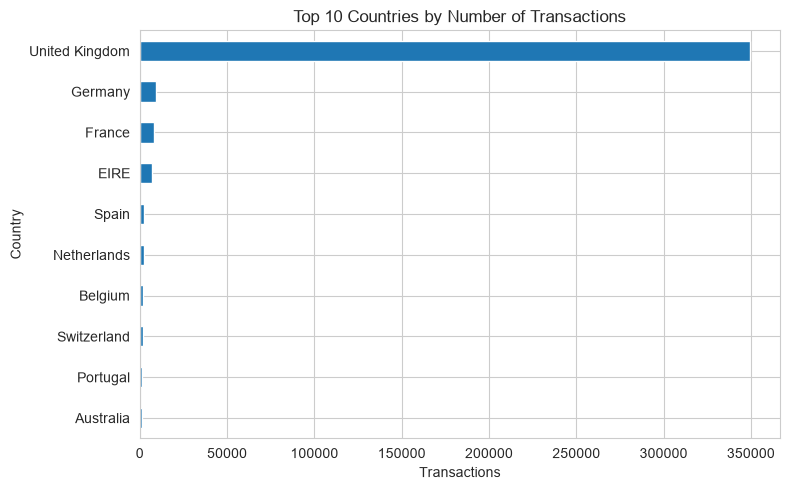

In [6]:
top_countries = df["Country"].value_counts().head(10)
top_countries.plot(kind="barh", title="Top 10 Countries by Number of Transactions")
plt.xlabel("Transactions")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


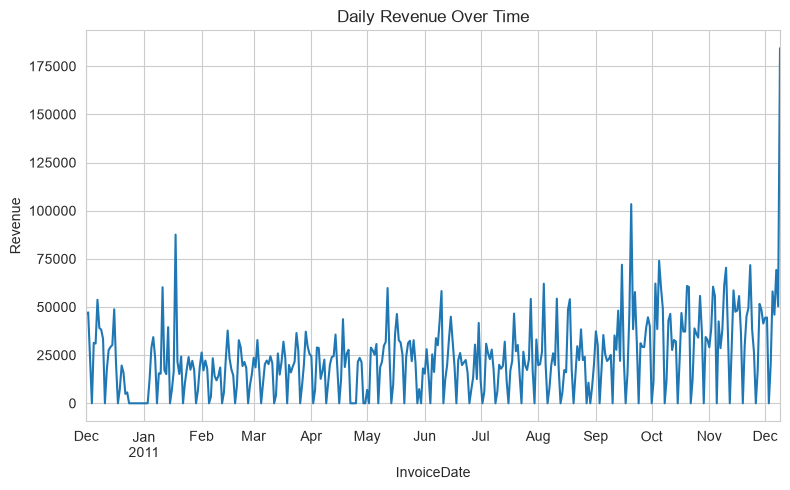

In [7]:
daily_sales = df.set_index("InvoiceDate").resample("D")["TotalPrice"].sum()
daily_sales.plot(title="Daily Revenue Over Time")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()


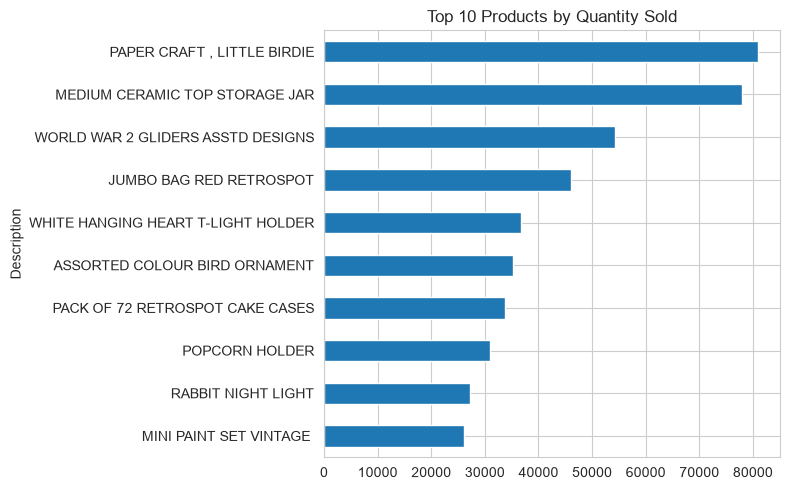

In [8]:
top_products = df.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(10)
top_products.plot(kind="barh", title="Top 10 Products by Quantity Sold")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## 4. RFM Feature Engineering

For each customer we compute:
- **Recency**: days since their last purchase
- **Frequency**: number of distinct orders
- **Monetary**: total amount spent


In [9]:
rfm = utils.calculate_rfm(df)
print(rfm.shape)
rfm.head()


(4338, 4)


,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


In [10]:
rfm.describe()


,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


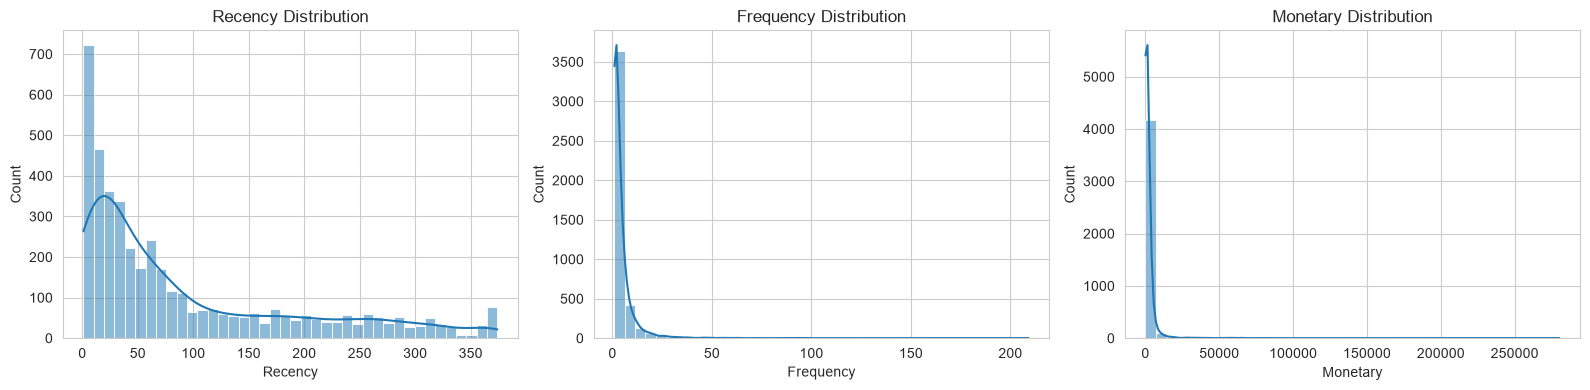

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ["Recency", "Frequency", "Monetary"]):
    sns.histplot(rfm[col], bins=40, ax=ax, kde=True)
    ax.set_title(f"{col} Distribution")
plt.tight_layout()
plt.show()


## 5. Log Transform & Scale

RFM features are heavily right-skewed, so we apply `log1p` before standard scaling —
this keeps distance-based clustering (KMeans/Hierarchical/DBSCAN all rely on distance)
from being dominated by outliers.


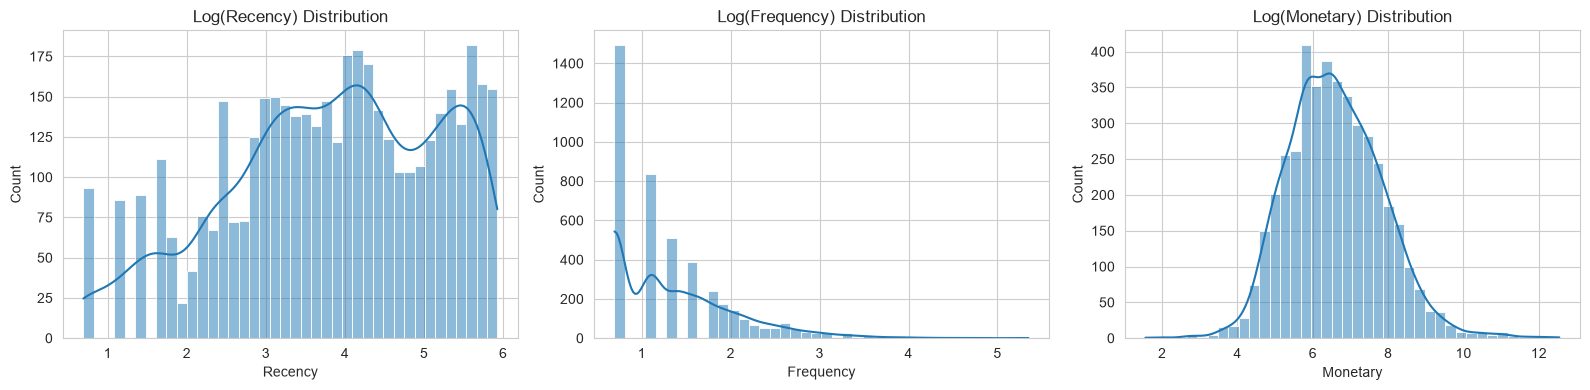

In [12]:
rfm_indexed = rfm.set_index("CustomerID")
log_rfm = utils.log_transform_rfm(rfm_indexed)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ["Recency", "Frequency", "Monetary"]):
    sns.histplot(log_rfm[col], bins=40, ax=ax, kde=True)
    ax.set_title(f"Log({col}) Distribution")
plt.tight_layout()
plt.show()


In [13]:
scaled_df, scaler = utils.scale_features(log_rfm, fit=True)
scaled_df.head()


,Recency,Frequency,Monetary
CustomerID,,,
12346,1.461993,-0.955214,3.707716
12347,-2.038734,1.074425,1.414903
12348,0.373104,0.386304,0.720024
12349,-0.623086,-0.955214,0.702287
12350,1.424558,-0.955214,-0.614514


## 6. Choose an Algorithm

Set `ALGORITHM` to one of `"kmeans"`, `"hierarchical"`, or `"dbscan"`, then fill in the
matching parameters below. Diagnostics differ by algorithm:
- **K-Means / Hierarchical**: use the elbow (inertia) + silhouette score to pick `N_CLUSTERS`.
- **DBSCAN**: use the k-distance plot to pick `EPS` (look for the "elbow" in the sorted curve).


In [14]:
ALGORITHM = "kmeans"  # "kmeans" | "hierarchical" | "dbscan"

# Used by kmeans / hierarchical
N_CLUSTERS = 4
LINKAGE = "ward"  # only used if ALGORITHM == "hierarchical": "ward" | "complete" | "average" | "single"

# Used by dbscan
EPS = 0.5
MIN_SAMPLES = 5


In [ ]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

if ALGORITHM in ("kmeans", "hierarchical"):
    inertias, silhouettes = [], []
    k_range = range(2, 10)
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(scaled_df)
        inertias.append(km.inertia_)
        silhouettes.append(silhouette_score(scaled_df, labels))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(list(k_range), inertias, marker="o")
    axes[0].set_title("Elbow Method (Inertia)")
    axes[0].set_xlabel("k")
    axes[0].set_ylabel("Inertia")

    axes[1].plot(list(k_range), silhouettes, marker="o", color="darkorange")
    axes[1].set_title("Silhouette Score")
    axes[1].set_xlabel("k")
    axes[1].set_ylabel("Silhouette Score")
    plt.tight_layout()
    plt.show()
else:
    k_dist = utils.compute_k_distance(scaled_df, k=MIN_SAMPLES)
    plt.plot(k_dist)
    plt.title("K-Distance Graph (look for the elbow to pick EPS)")
    plt.xlabel("Points (sorted)")
    plt.ylabel(f"Distance to {MIN_SAMPLES}-th nearest neighbor")
    plt.tight_layout()
    plt.show()


Adjust `N_CLUSTERS`/`LINKAGE` (for K-Means/Hierarchical) or `EPS`/`MIN_SAMPLES` (for
DBSCAN) above based on the diagnostic plot, then continue.


In [ ]:
if ALGORITHM == "kmeans":
    model, cluster_labels, supports_predict = utils.run_clustering(
        "kmeans", scaled_df, n_clusters=N_CLUSTERS
    )
elif ALGORITHM == "hierarchical":
    model, cluster_labels, supports_predict = utils.run_clustering(
        "hierarchical", scaled_df, n_clusters=N_CLUSTERS, linkage=LINKAGE
    )
else:
    model, cluster_labels, supports_predict = utils.run_clustering(
        "dbscan", scaled_df, eps=EPS, min_samples=MIN_SAMPLES
    )

print("Algorithm:", ALGORITHM, "| supports future .predict():", supports_predict)
print("Cluster counts:")
print(pd.Series(cluster_labels).value_counts())

rfm_indexed["Cluster"] = cluster_labels
rfm_indexed.head()


## 7. PCA for Visualization

In [ ]:
pca_df, pca = utils.apply_pca(scaled_df, fit=True, n_components=2)
print("Explained variance ratio:", pca.explained_variance_ratio_)

plot_df = pca_df.copy()
plot_df["Cluster"] = cluster_labels

plt.figure(figsize=(8, 6))
sns.scatterplot(data=plot_df, x="PC1", y="PC2", hue="Cluster", palette="tab10", alpha=0.7)
plt.title(f"Customer Clusters ({ALGORITHM}, PCA-reduced RFM space)")
plt.tight_layout()
plt.show()


## 8. Profile & Name Segments

We compute the mean Recency/Frequency/Monetary per cluster, then heuristically
assign human-readable segment names (e.g. *Champions*, *At Risk*, *Hibernating*).
DBSCAN's noise cluster (`-1`), if present, is always labeled *Noise / Outliers*.


In [ ]:
cluster_profile = rfm_indexed.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean().round(1)
cluster_profile["Count"] = rfm_indexed.groupby("Cluster").size()
cluster_profile


In [ ]:
cluster_to_segment = utils.label_segments(rfm_indexed, cluster_col="Cluster")
cluster_to_segment


In [ ]:
rfm_indexed["Segment"] = rfm_indexed["Cluster"].map(cluster_to_segment)
rfm_indexed["Segment"].value_counts()


In [ ]:
plot_df["Segment"] = plot_df["Cluster"].map(cluster_to_segment)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=plot_df, x="PC1", y="PC2", hue="Segment", palette="tab10", alpha=0.7)
plt.title("Customer Segments (PCA-reduced RFM space)")
plt.tight_layout()
plt.show()


In [ ]:
for cluster_id, name in cluster_to_segment.items():
    print(f"Cluster {cluster_id} -> {name}: {utils.SEGMENT_DESCRIPTIONS.get(name, '')}")


## 9. Save Models

Save the fitted `scaler`, `pca`, and clustering model so `app.py` can reuse the exact same
preprocessing/clustering pipeline on new data.

**Important:** only save/rely on this for the **Quick Lookup** tab in `app.py` if
`ALGORITHM == "kmeans"` — Hierarchical and DBSCAN models saved here can be reloaded and
inspected, but `app.py` will correctly refuse to use them for scoring new data, since
scikit-learn's implementations of those two don't support `.predict()` on unseen points.


In [ ]:
import os

MODELS_DIR = "../models"
os.makedirs(MODELS_DIR, exist_ok=True)

utils.save_model(scaler, os.path.join(MODELS_DIR, "scaler.pkl"))
utils.save_model(pca, os.path.join(MODELS_DIR, "pca.pkl"))

# Bundle the model together with its metadata so app.py knows how to use it
cluster_bundle = {
    "algorithm": ALGORITHM,
    "mode": "rfm",
    "model": model,
    "cluster_to_segment": cluster_to_segment,
    "numeric_cols": [],
    "categorical_cols": [],
}
utils.save_model(cluster_bundle, os.path.join(MODELS_DIR, "cluster_model.pkl"))

print("Saved scaler.pkl, pca.pkl, cluster_model.pkl to", MODELS_DIR)
print("Saved algorithm:", ALGORITHM, "| usable for Quick Lookup in app.py:", supports_predict)


## 10. Conclusion

The trained pipeline segments customers into actionable groups based on purchase
recency, frequency, and spend. Run `streamlit run app.py` from the project root — use the
**Upload & Cluster (Live)** tab to try all three algorithms interactively on any CSV, or the
**Quick Lookup** tab to score new customers against whichever K-Means model is currently saved
in `models/` (from this notebook, or from the app's own "save" button).
